In [87]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate

In [ ]:
# The inital state, is in Sx

device="cpu"
tfinal=10
waveFunction=torch.tensor([1/np.sqrt(2),1/np.sqrt(2)],device=device,dtype=torch.complex64)
rhoInit=torch.outer(waveFunction,waveFunction.conj())

hbar=1
m=1
N=500
omega=1
sz=torch.tensor([[1,0],[0,-1]],dtype=torch.complex64)
sy =torch.tensor([[0,-1j],[1j,0]],dtype=torch.complex64)
sx = torch.tensor([[0,1],[1,0]],dtype=torch.complex64)
hamilTonian=hbar*omega*0.5*sz
def evolution(t,rho_flat):
    rho=torch.tensor(rho_flat,dtype=torch.complex64).reshape(2,2)
    dRho=-1j*(hamilTonian @ rho-rho @ hamilTonian)
    return dRho.flatten()
tlisit=torch.linspace(0,tfinal,N)
sol=integrate.solve_ivp(evolution,t_span=[0,tfinal],t_eval=tlisit,y0=rhoInit.flatten().numpy())
totalRho=torch.tensor(sol.y.T,dtype=torch.complex64).reshape((N,2,2))

meansx=[]
meansy=[]
meansz=[]

for i in range(len(tlisit)):
    avgsx=totalRho[i] @ sx
    avgsx=(torch.trace(avgsx))
    meansx.append(avgsx.numpy())
    avgsy=totalRho[i] @ sy
    avgsy=(torch.trace(avgsy))
    meansy.append(avgsy.numpy())
    avgsz=totalRho[i] @ sz
    avgsz=torch.trace(avgsz)
    meansz.append(avgsz.numpy())




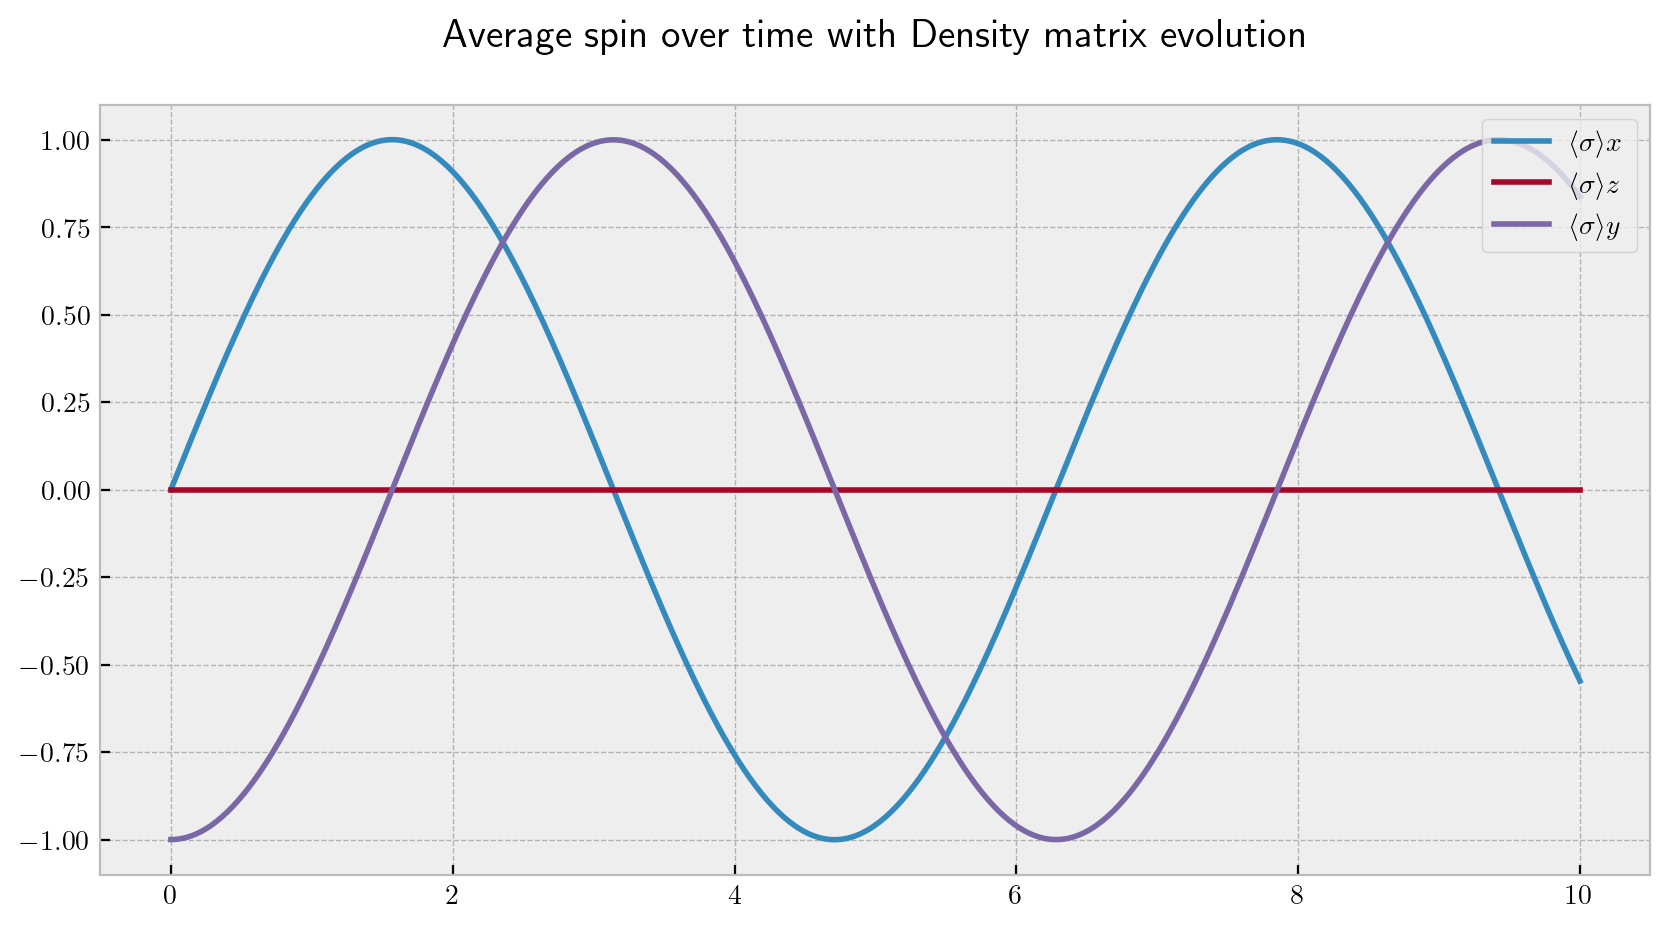

In [89]:
plt.rcParams['text.usetex'] = True
plt.style.use('bmh')
plt.figure(figsize=(10,5),dpi=200)
plt.plot(tlisit,np.real(meansx),label="$\\langle \\sigma \\rangle x$")
plt.plot(tlisit,np.real(meansz),label="$\\langle \\sigma \\rangle z$")
plt.plot(tlisit,np.real(meansy),label="$\\langle \\sigma \\rangle y$")
plt.legend(loc="upper right")
plt.title("Average spin over time with Density matrix evolution\n",fontdict=dict(fontweight="bold"))
plt.show()

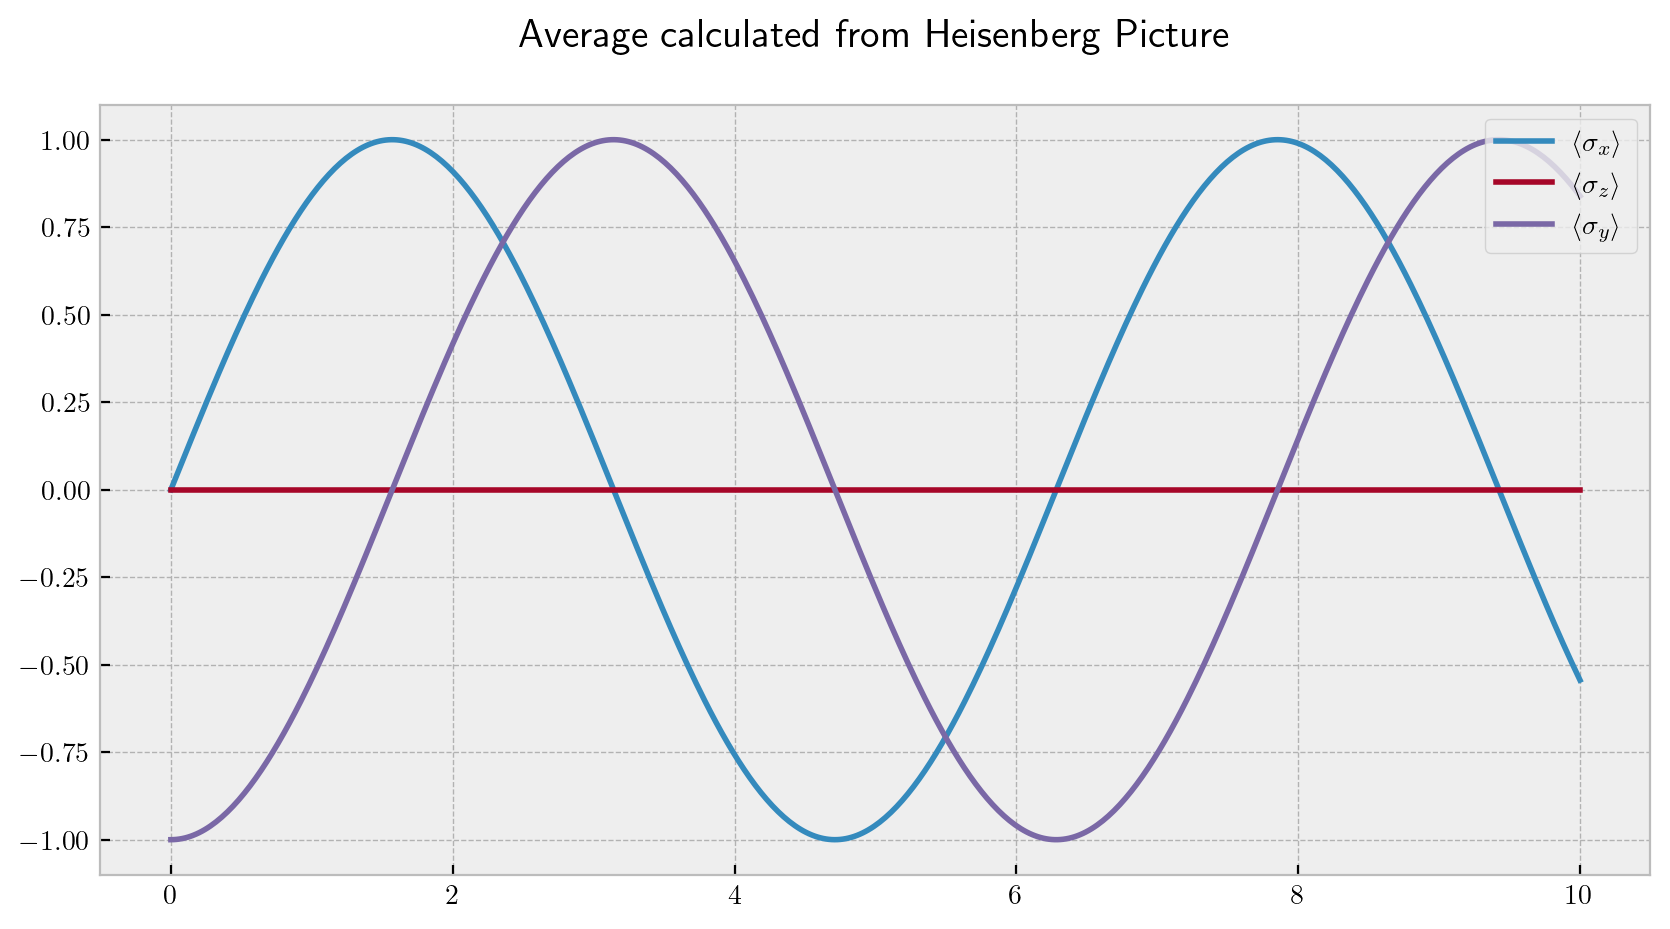

In [90]:
plt.rcParams['text.usetex'] = True
plt.style.use('bmh')
plt.figure(figsize=(10,5),dpi=200)

def operatorEvolution(hamilTonian,time,operator):
    ev= torch.matrix_exp(-1j*hamilTonian*time)
    evT=(torch.conj(ev).T)@operator@ev
    return evT

meansxlist=[ torch.vdot(waveFunction,operatorEvolution(hamilTonian,t,sx)@waveFunction) for t in tlisit ]
plt.plot(tlisit,np.real(meansxlist),label="$\\langle \\sigma_x \\rangle$")
meanszlist=[ torch.vdot(waveFunction,operatorEvolution(hamilTonian,t,sz)@waveFunction) for t in tlisit ]
plt.plot(tlisit,np.real(meanszlist),label="$\\langle \\sigma_z \\rangle$")
meansylist=[ torch.vdot(waveFunction,operatorEvolution(hamilTonian,t,sy)@waveFunction) for t in tlisit ]
plt.plot(tlisit,np.real(meansylist),label="$\\langle \\sigma_y \\rangle$")

plt.legend(loc="upper right")
plt.title("Average calculated from Heisenberg Picture\n")
plt.show()

